In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px


In [2]:
path = os.path.expanduser("~/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/IEA_Global_EV_Data_2024.csv")

# Load the data
ev_data = pd.read_csv(path)

# Quick look at the structure
print(ev_data.info())
display(ev_data.head())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/joshua/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/IEA_Global_EV_Data_2024.csv'

In [29]:
## Make copy
# Renaming 'region' to 'country'
ev_data_3 = ev_data
ev_data_3 = ev_data.rename(columns={'region': 'country'})

# Verify the change
print(ev_data.columns)

Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value'],
      dtype='str')


In [33]:
# 1) year is already a year number (2011, 2012, ...), keep it numeric
ev_data_3['year_clean'] = pd.to_numeric(ev_data_3['year'], errors='coerce').astype('Int64')

# (optional but recommended) ensure value is numeric
ev_data_3['value'] = pd.to_numeric(ev_data_3['value'], errors='coerce')

# 2) Filter
aggregates = ['World', 'Europe', 'EU27', 'Rest of the world']
filtered_data = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales') &
    (~ev_data_3['country'].isin(aggregates)) &
    (ev_data_3['year_clean'] < 2025)
]

# 3) Group, sort, top 20
top_20_data = (
    filtered_data.groupby('country', as_index=False)['value']
    .sum()
    .sort_values(by='value', ascending=False)
    .head(20)
)

# 4) Plot
fig = px.bar(
    top_20_data,
    x='country',
    y='value',
    color='country',
    title="Top 20 Regions: Total EV Sales (Pre-2025)",
    labels={'country': "Country", 'value': 'Total Vehicles'}
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='black',
    font=dict(color='white'),
    xaxis_tickangle=-45
)

fig.show()


In [39]:
# 1) year is already a year number (2011, 2012, ...), keep it numeric
ev_data_3['year_clean'] = pd.to_numeric(ev_data_3['year'], errors='coerce').astype('Int64')

# (optional but recommended) ensure value is numeric
ev_data_3['value'] = pd.to_numeric(ev_data_3['value'], errors='coerce')

# 2) Filter
aggregates = ['World', 'Europe', 'EU27', 'Rest of the world']
filtered_data = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales') &
    (~ev_data_3['country'].isin(aggregates)) &
    (ev_data_3['year_clean'] <= 2025)
]

# 3) Group, sort, top 20
top_20_data = (
    filtered_data.groupby('country', as_index=False)['value']
    .sum()
    .sort_values(by='value', ascending=False)
    .head(20)
)

# 4) Plot
fig = px.bar(
    top_20_data,
    x='country',
    y='value',
    color='country',
    title="Top 20 Regions: Total EV Sales (2035)",
    labels={'country': "Country", 'value': 'Total Vehicles'}
)

fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='black',
    font=dict(color='white'),
    xaxis_tickangle=-45
)

fig.show()


In [34]:
print(ev_data_3['year'].max())
print(ev_data_3['year'].min())

2035
2010


/var/folders/gz/6c8jn9211fg0pdtxyqhhg3pw0000gn/T/ipykernel_56330/934208219.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




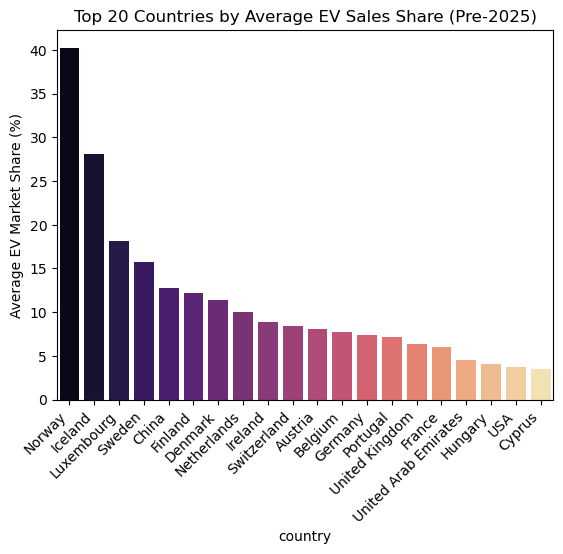

In [37]:
aggregates = ['World', 'Europe', 'EU27', 'Rest of the world']

# Ensure numeric year
ev_data_3['year_clean'] = pd.to_numeric(ev_data_3['year'], errors='coerce')

share_data = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales share') &
    (~ev_data_3['country'].isin(aggregates)) &
    (ev_data_3['year_clean'] < 2025) &
    (ev_data_3['mode'] == 'Cars') &
    (ev_data_3['powertrain'] == 'EV')   # change if you want BEV only
].copy()

# Convert to percent if values are fractions
# If your data is already 0–100, remove this block.
if share_data['value'].max() <= 1.0:
    share_data['value_plot'] = share_data['value'] * 100
    ylab = 'Average EV Market Share (%)'
else:
    share_data['value_plot'] = share_data['value']
    ylab = 'Average EV Market Share (%)'

top_share_countries = (
    share_data.groupby('country', as_index=False)['value_plot']
    .mean()
    .sort_values('value_plot', ascending=False)
    .head(20)
)

sns.barplot(data=top_share_countries, x='country', y='value_plot', palette="magma")
plt.xticks(rotation=45, ha='right')
plt.ylabel(ylab)
plt.title('Top 20 Countries by Average EV Sales Share (Pre-2025)')
plt.show()


## D3 Ready


/var/folders/gz/6c8jn9211fg0pdtxyqhhg3pw0000gn/T/ipykernel_56330/532551663.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




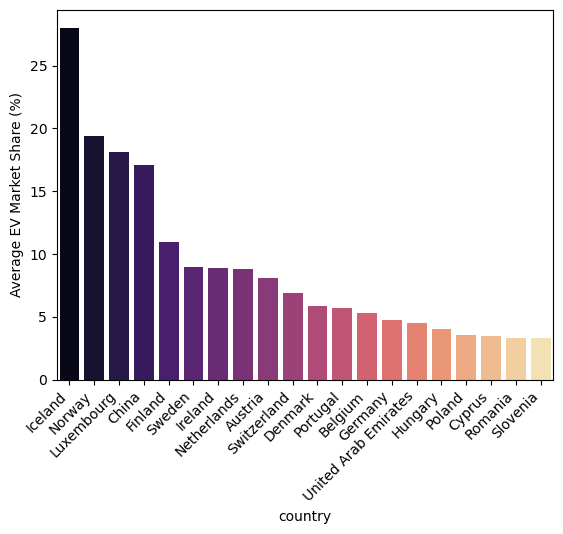

In [36]:
# Filter for 'EV sales share' instead of 'EV sales'
share_data = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales share') & 
    (~ev_data_3['country'].isin(aggregates)) & 
    (ev_data_3['year'] < 2025)
]

# We use .mean() because percentages shouldn't be summed across years
top_share_countries = (share_data.groupby('country')['value']
                       .mean()
                       .sort_values(ascending=False)
                       .head(20)
                       .reset_index())

# Plotting

sns.barplot(data=top_share_countries, x='country', y='value', palette="magma")

# Add this line to rotate the country names
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Average EV Market Share (%)')
plt.show()

In [8]:
from pathlib import Path

out = Path("frontend/public/data")
out.mkdir(parents=True, exist_ok=True)

d3_df = top_share_countries.copy()
d3_df["value"] = d3_df["value"].astype(float)

d3_df.to_csv(out / "top_ev_sales_share_countries.csv", index=False)


In [9]:
print((out / "top_ev_sales_share_countries.csv").resolve())
print((out / "top_ev_sales_share_countries.csv").exists())
d3_df.head()


/Users/joshua/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/Merge Folder/frontend/public/data/top_ev_sales_share_countries.csv
True


,country,value
0,Iceland,28.027500
1,China,24.618804
2,Norway,19.415390
3,Luxembourg,18.100000
4,USA,15.685943


In [21]:
print(ev_data_3['year'].max())
print(ev_data_3['year'].min())


2035
2010


In [16]:
selected_year = 2030

share_data_year = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales share') &
    (~ev_data_3['country'].isin(aggregates)) &
    (ev_data_3['year_clean'] == selected_year)
]

top_share_countries = (
    share_data_year.sort_values('value', ascending=False)
    .head(20)
)


## D3 Ready 2

In [40]:
import pandas as pd
import json

# Clean
ev_data_3['year_clean'] = pd.to_numeric(ev_data_3['year'], errors='coerce').astype('Int64')
ev_data_3['value'] = pd.to_numeric(ev_data_3['value'], errors='coerce')

aggregates = ['World', 'Europe', 'EU27', 'Rest of the world']

# Keep EV sales only; keep all years you have (<=2035 if you want)
d3_df = ev_data_3[
    (ev_data_3['parameter'] == 'EV sales') &
    (~ev_data_3['country'].isin(aggregates)) &
    (ev_data_3['year_clean'].notna())
].copy()

# If you want cap to 2035:
d3_df = d3_df[d3_df['year_clean'] <= 2035]

# Aggregate in case you have multiple rows per country-year (by powertrain/category/etc.)
d3_df = (
    d3_df.groupby(['year_clean', 'country'], as_index=False)['value']
    .sum()
    .rename(columns={'year_clean': 'year', 'value': 'ev_sales'})
)

# Save
out_path = "frontend/public/data/ev_sales_by_country_year.json"
d3_df.to_json(out_path, orient="records")
print("Saved:", out_path, "rows:", len(d3_df))


Saved: frontend/public/data/ev_sales_by_country_year.json rows: 562
